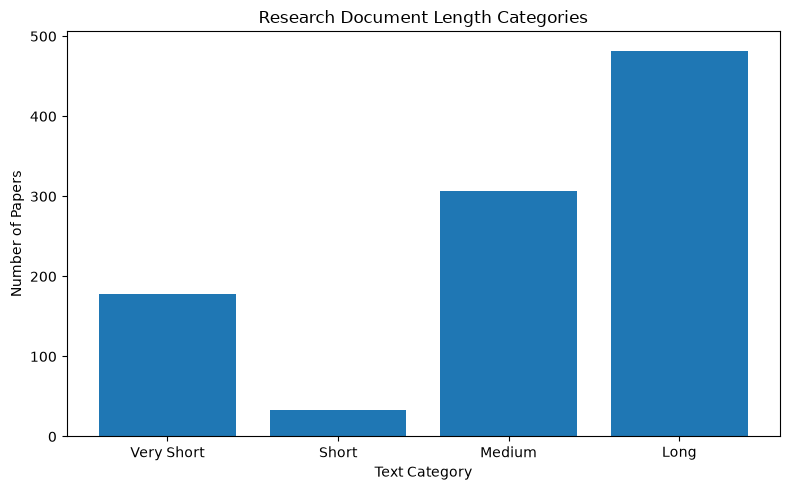

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.title("Research Document Length Categories")
plt.xlabel("Text Category")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

In [21]:
quality_counts = (
    df["semantic_quality"]
    .value_counts()
    .reindex([
        "Very Short",
        "Short",
        "Medium",
        "Long"
    ])
)

quality_counts

semantic_quality
Very Short    178
Short          33
Medium        307
Long          482
Name: count, dtype: int64

In [20]:
df["has_abstract"] = (
    df["abstract"]
    .str.strip()
    .str.len()
    .gt(0)
)

df["semantic_quality"] = pd.cut(
    df["text_length"],
    bins=[-1, 29, 99, 199, float("inf")],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long"
    ]
)

df[
    [
        "title",
        "text_length",
        "has_abstract",
        "semantic_quality"
    ]
].head(20)

,title,text_length,has_abstract,semantic_quality
0,Application of artificial intelligence techniq...,158,True,Medium
1,Educational Innovation in Engineering: Integra...,157,True,Medium
2,From Pixels to States: Rethinking Interactive ...,247,True,Long
3,"Systematic co-optimization from chip design, p...",13,False,Very Short
4,AI in Multidisciplinary Engineering: A Holisti...,172,True,Medium
5,NOAAGlobalTemp version 6: An AI-based global s...,251,True,Long
6,Artificial intelligence iterative reconstructi...,266,True,Long
7,AI Risk Mitigation Proposal for Enterprise Tec...,432,True,Long
8,"Rise of Computer-Related Crimes: Loss of Data,...",273,True,Long
9,Deep Learning Approaches for Pneumonia Detecti...,195,True,Medium


In [18]:
short_papers[
    ["paperId", "title", "abstract", "text_length"]
].head(20)

,paperId,title,abstract,text_length
3,00003fb6543527decf90df0ff3719396a8ee2330,"Systematic co-optimization from chip design, p...",,13
15,0001bef437ce6415a32933c7aaf57366fb52762a,Reply to: Correction to external evaluation of...,,24
21,0002c17d58ee6989a50bbe078ccd4faf869c50e5,Review of fruit sourness: Formation mechanisms...,,17
25,000389ab9f1d01978d98a0b13c61361bf22c6f87,Artificial Intelligence and Endoscopist Diagno...,,15
33,000485ccd16213bb085d74f4f1fec4ba7240b8c7,Artificial Intelligence and Information Litera...,,8
34,000494514a9594043888004fe540566a97f98687,THE ROLE OF ARTIFICIAL INTELLIGENCE IN SHAPING...,,10
37,0004dc52be3d88442e2af7399bc73b1e554122d7,[Delivering with Intelligence: Integrating Art...,,9
44,0005ec4203caf35412ad2780e7d02f966fc31a21,Law and Regulation of Artificial Intelligence ...,,10
53,0006aad39b35ca1ca15c34db00057477326d10a1,Videojuego con sistema inteligente de aprendiz...,,9
59,000744aac817dc5ed056920cab5ad4155236d044,Innovation and Governance of Corporate Social ...,,13


In [17]:
short_papers = df[
    df["text_length"] < 30
]

print(
    "Papers with fewer than 30 words:",
    len(short_papers)
)

print(
    f"Percentage of corpus: "
    f"{len(short_papers) / len(df) * 100:.2f}%"
)

Papers with fewer than 30 words: 178
Percentage of corpus: 17.80%


In [16]:
long_papers = df[
    df["text_length"] > 1000
]

print(
    "Papers with more than 1000 words:",
    len(long_papers)
)

Papers with more than 1000 words: 0


In [15]:
short_papers = df[
    df["text_length"] < 30
]

print(
    "Papers with fewer than 30 words:",
    len(short_papers)
)

short_papers[
    ["title", "abstract", "text_length"]
].head(20)

Papers with fewer than 30 words: 178


,title,abstract,text_length
3,"Systematic co-optimization from chip design, p...",,13
15,Reply to: Correction to external evaluation of...,,24
21,Review of fruit sourness: Formation mechanisms...,,17
25,Artificial Intelligence and Endoscopist Diagno...,,15
33,Artificial Intelligence and Information Litera...,,8
34,THE ROLE OF ARTIFICIAL INTELLIGENCE IN SHAPING...,,10
37,[Delivering with Intelligence: Integrating Art...,,9
44,Law and Regulation of Artificial Intelligence ...,,10
53,Videojuego con sistema inteligente de aprendiz...,,9
59,Innovation and Governance of Corporate Social ...,,13


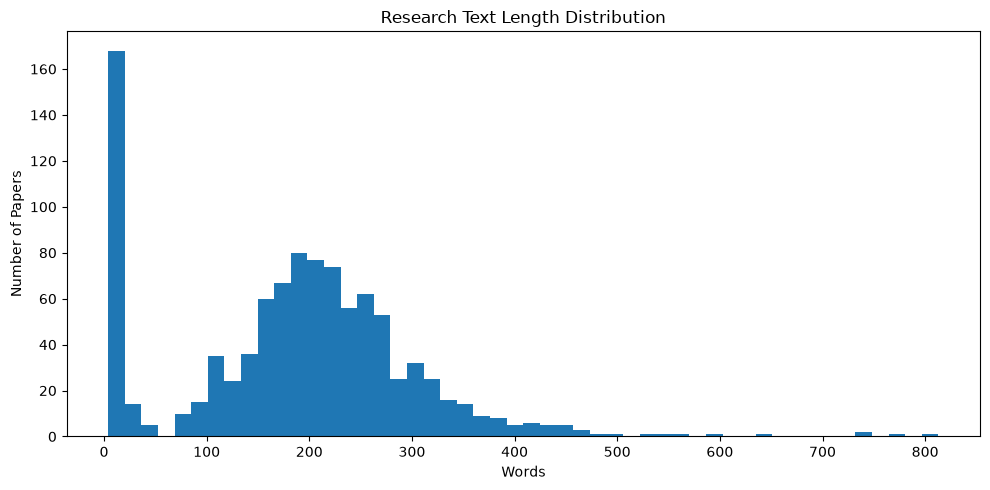

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Research Text Length Distribution")
plt.xlabel("Words")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

In [13]:
df["text_length"] = (
    df["text"]
    .str.split()
    .str.len()
)

df["text_length"].describe()

count    1000.000000
mean      187.202000
std       115.831404
min         4.000000
25%       121.000000
50%       196.000000
75%       253.000000
max       813.000000
Name: text_length, dtype: float64

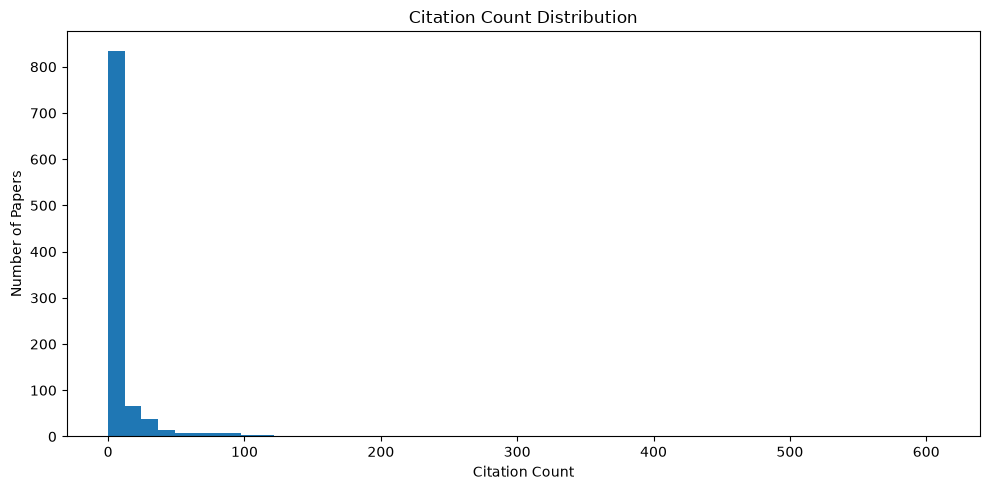

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["citationCount"],
    bins=50
)

plt.title("Citation Count Distribution")
plt.xlabel("Citation Count")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

In [11]:
df["citationCount"].describe()

count    1000.000000
mean       10.559000
std        36.994853
min         0.000000
25%         0.000000
50%         1.000000
75%         6.000000
max       609.000000
Name: citationCount, dtype: float64

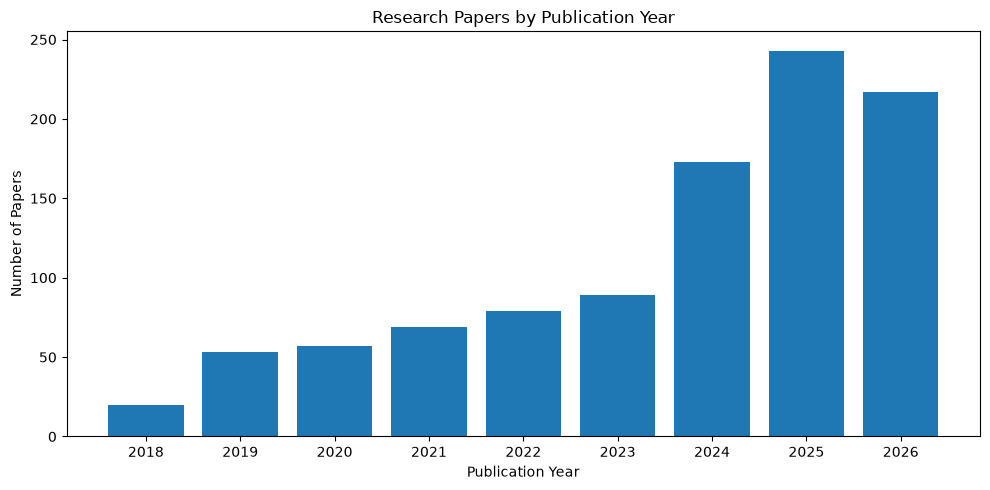

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    year_counts.index.astype(str),
    year_counts.values
)

plt.title("Research Papers by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

In [9]:
year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

year_counts

year
2018     20
2019     53
2020     57
2021     69
2022     79
2023     89
2024    173
2025    243
2026    217
Name: count, dtype: int64

In [8]:
print(
    "Duplicate paper IDs:",
    df["paperId"].duplicated().sum()
)

print(
    "Duplicate titles:",
    df["title"].duplicated().sum()
)

Duplicate paper IDs: 0
Duplicate titles: 0


In [7]:
abstract_available = (
    df["abstract"].str.strip().str.len() > 0
)

print(
    f"Abstract available: {abstract_available.sum()}"
)

print(
    f"Abstract missing: {(~abstract_available).sum()}"
)

print(
    f"Abstract coverage: "
    f"{abstract_available.mean() * 100:.2f}%"
)

Abstract available: 825
Abstract missing: 175
Abstract coverage: 82.50%


In [6]:
missing = df.isna().sum()

missing_percentage = (
    missing / len(df) * 100
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_report = missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

missing_report

,missing_count,missing_percentage
fieldsOfStudy,571,57.1
publicationDate,122,12.2
title,0,0.0
venue,0,0.0
paperId,0,0.0
url,0,0.0
referenceCount,0,0.0
year,0,0.0
isOpenAccess,0,0.0
citationCount,0,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   paperId          1000 non-null   str   
 1   url              1000 non-null   str   
 2   title            1000 non-null   str   
 3   venue            1000 non-null   str   
 4   year             1000 non-null   int64 
 5   referenceCount   1000 non-null   int64 
 6   citationCount    1000 non-null   int64 
 7   isOpenAccess     1000 non-null   bool  
 8   openAccessPdf    1000 non-null   object
 9   fieldsOfStudy    429 non-null    object
 10  publicationDate  878 non-null    str   
 11  authors          1000 non-null   object
 12  abstract         1000 non-null   str   
 13  text             1000 non-null   str   
dtypes: bool(1), int64(3), object(3), str(7)
memory usage: 2.9+ MB


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 14


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "papers_clean.parquet"
)

df = pd.read_parquet(DATA_FILE)

df.head()

,paperId,url,title,venue,year,referenceCount,citationCount,isOpenAccess,openAccessPdf,fieldsOfStudy,publicationDate,authors,abstract,text
0,000011f43bed0f6830c9cbcc76a7863bf57421ea,https://www.semanticscholar.org/paper/000011f4...,Application of artificial intelligence techniq...,,2020,1,10,False,"{'url': '', 'status': None, 'license': None, '...",[Environmental Science],2020-11-27,"[{'authorId': '2375922570', 'name': 'T. M. Nav...",Abstract Agriculture is the backbone of all de...,Application of artificial intelligence techniq...
1,000031e564c267a1c7816fb1938ef152b8872f03,https://www.semanticscholar.org/paper/000031e5...,Educational Innovation in Engineering: Integra...,2025 IEEE Engineering Education World Conferen...,2025,21,3,False,"{'url': '', 'status': 'CLOSED', 'license': Non...",None,2025-03-23,"[{'authorId': '2298178063', 'name': 'Jorge Alv...",This article presents a study on educational i...,Educational Innovation in Engineering: Integra...
2,0000394359444bb2dac72249d8609fa0bc0df2d7,https://www.semanticscholar.org/paper/00003943...,From Pixels to States: Rethinking Interactive ...,arXiv.org,2026,114,2,False,"{'url': '', 'status': None, 'license': None, '...",[Computer Science],2026-07-15,"[{'authorId': '2354248672', 'name': 'Zhen Li'}...",Building interactive worlds that respond coher...,From Pixels to States: Rethinking Interactive ...
3,00003fb6543527decf90df0ff3719396a8ee2330,https://www.semanticscholar.org/paper/00003fb6...,"Systematic co-optimization from chip design, p...","International Symposium on VLSI Technology, Sy...",2018,1,12,False,"{'url': '', 'status': 'CLOSED', 'license': Non...",[Computer Science],2018-04-16,"[{'authorId': '49268145', 'name': 'John R. Hu'...",,"Systematic co-optimization from chip design, p..."
4,000099a8f4c7604b553963915427b46ad4b6e491,https://www.semanticscholar.org/paper/000099a8...,AI in Multidisciplinary Engineering: A Holisti...,International Research Journal on Advanced Sci...,2025,12,1,True,{'url': 'https://rspsciencehub.com/index.php/j...,None,2025-12-26,"[{'authorId': None, 'name': 'G. Gayatri Tanuja...",Artificial Intelligence (AI) has evolved from ...,AI in Multidisciplinary Engineering: A Holisti...


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt